## Threshold Tuning and Model Optimization Analysis

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt

results = pd.read_csv("member3_day1_w4results.csv")

y_true = results["Actual"].values
y_proba = results["Failure Probability"].values

print("Data loaded successfully")

Data loaded successfully


In [2]:
thresholds = np.arange(0.1, 0.9, 0.05)
print("Thresholds:", thresholds)

Thresholds: [0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65 0.7  0.75
 0.8  0.85]


In [3]:
def evaluate_threshold(y_true, y_proba, threshold):
    y_pred = (y_proba >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    return {
        "threshold": threshold,
        "tp": tp,
        "fp": fp,
        "tn": tn,
        "fn": fn,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [4]:
results_list = []
for t in thresholds:
    results_list.append(evaluate_threshold(y_true, y_proba, t))
df_results = pd.DataFrame(results_list)

df_results

,threshold,tp,fp,tn,fn,precision,recall,f1
0,0.10,67,474,1458,1,0.123845,0.985294,0.220033
1,0.15,67,343,1589,1,0.163415,0.985294,0.280335
2,0.20,67,264,1668,1,0.202417,0.985294,0.335840
3,0.25,67,195,1737,1,0.255725,0.985294,0.406061
4,0.30,67,159,1773,1,0.296460,0.985294,0.455782
5,0.35,67,127,1805,1,0.345361,0.985294,0.511450
6,0.40,67,99,1833,1,0.403614,0.985294,0.572650
7,0.45,67,83,1849,1,0.446667,0.985294,0.614679
8,0.50,66,67,1865,2,0.496241,0.970588,0.656716
9,0.55,66,48,1884,2,0.578947,0.970588,0.725275


In [5]:
best_row = df_results.loc[df_results["f1"].idxmax()]

print("Best Threshold Based on F1 Score:")
print(best_row)

Best Threshold Based on F1 Score:
threshold       0.800000
tp             65.000000
fp              6.000000
tn           1926.000000
fn              3.000000
precision       0.915493
recall          0.955882
f1              0.935252
Name: 14, dtype: float64


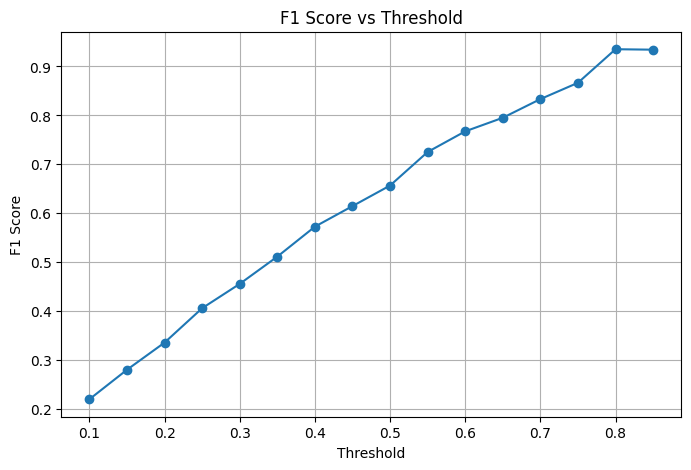

In [6]:
plt.figure(figsize=(8,5))
plt.plot(df_results["threshold"], df_results["f1"], marker="o")

plt.title("F1 Score vs Threshold")
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.grid()
plt.show()

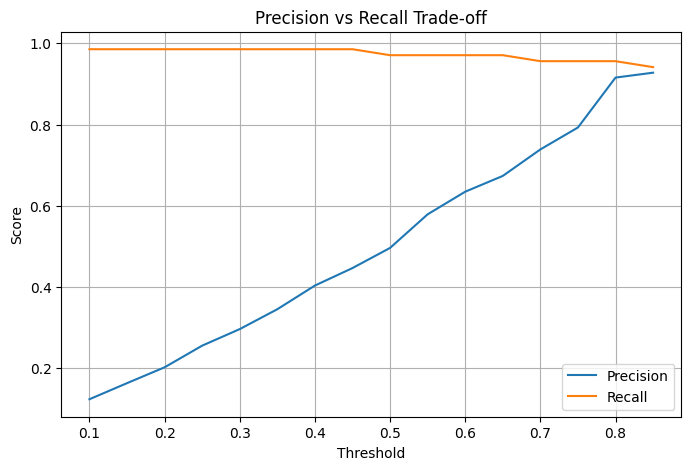

In [7]:
plt.figure(figsize=(8,5))
plt.plot(df_results["threshold"], df_results["precision"], label="Precision")
plt.plot(df_results["threshold"], df_results["recall"], label="Recall")

plt.title("Precision vs Recall Trade-off")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.grid()
plt.show()

In [8]:
print("=== BUSINESS INTERPRETATION ===")

print("Lower threshold → More failures detected (high recall, more false alarms)")
print("Higher threshold → Fewer false alarms (high precision, more missed failures)")

print("\nBest threshold (F1 optimal):", best_row["threshold"])
print("Precision at best:", best_row["precision"])
print("Recall at best:", best_row["recall"])

=== BUSINESS INTERPRETATION ===
Lower threshold → More failures detected (high recall, more false alarms)
Higher threshold → Fewer false alarms (high precision, more missed failures)

Best threshold (F1 optimal): 0.8000000000000002
Precision at best: 0.9154929577464789
Recall at best: 0.9558823529411765
